VQ-VAE: LA RIVOLUZIONE DELLO SPAZIO LATENTE DISCRETO

Il mondo attorno a noi è davvero così fluido?
La parloe sono distinte, gli oggetti hanno parti definite e i mattoni di una casa sono unità discrete.

Con il VQ-VAE, Vector Quantized Variational Autoencoder, cambia il concetto di spazio latente.
Nel VAE classico ha uno spazio latente continuo. Ogni componente può assumere infiniti valori reali.

Nel VQ-VAE invece lo spazio latente diventa discreto. Il modello non usa qualunque vettore possibile: sceglie tra un insieme finito di vettori appresi, chiamato codebook

L'ai ha smesso di disegnare a mano libera, ed ha iniziato a rappresentare la realtà con un set di timbri o mattoni predefiniti.

VQ-VAE
input -> Encoder -> rappresentazione continua z_e -> QUANTIZZAZIONE -> vettore del codebook z_q -> Decoder -> Ricostruzione
La novità vera è tutto nel blocco centrale

E' come un arrotondamento di un valore decimali ma su vettori multidimensionali invece che singoli valori
Il codebook può essere visto come un vocabolario dovre prendere l'elemento (vettore di numeri) più vicino al vettore generato dell'Encoder a partire dall'immagine
immagine -> Encoder -> z_e -> cerco il codice più vicino -> CODEBOOK -> z_q -> Decoder -> immagine ricostruita

Perchè abbandonare la nuvola di punta dei VAE classici?
Sostituire la stocasticità con la selezione.
Il VAE è un sistema che mappa i dati in una nuvola di probabilità continua, dove ogni punto è un'interpolazione infinita. Ogni immagine è mappata in una nuvola dove ogni punto è un interpolazione infinita.
l Vector Quantized VAE (VQ-VAE) rompe questo schema introducendo una griglia di punti fissi: lo spazio latente non è più un oceano, ma un insieme finito di mattoni digitali. Passiamo dalla pittura ad olio, dove i colori si mescolano senza confino, ai mottoni lego, hai a disposizione solo certi pezzi

Questa restizione sembra un limiti ma in realtà è una forza incredibile. Obbliga la rete a creare una struttura logica e categorica.

La Quantizzazione Vettoriale
La scelta del pezzo giusto, assegnare il mattone più vicino.
L'encoder riceve l'input produce un output (vettore) continuo. Questo vettore non viene passato direttamente al Decoder. La rete consulta una tabella, il codebook, e cerca il vettore più simile a quello prodotto. E' un'operazione di prossimità, prendiamo il mattono che meglio approssima l'idea dell'encoder
Questa operazione trasforma la rappresentazione latente in una sequenza di indici discreti, eliminando la necessità di campionare con il reparameterization trick (rumore gaussiano).
Il decoder riceve questi indici quantizzati e impara a ricostruire l'immagine originale partendo solo da questi atomi informativi.
Il vantaggio principlae è la stabilità: non c'è rischio che la KL divergence schiacci troppo lo spazio, perchè il vincolo è strutturale e non statistico.

Per capire meglio uso l'analogia dello scrittore
Nel VAE standard la rete scrive come se usasse la penna: può tracciare qualsiasi curva, ma se la mano trema o l'inchiostro sbava (rumore stocastico) il risultato è difficile da leggere (VAE come tema a mano libera).
Nel VQ-VAE la rete ha a disposizoine dei timbri con lettere predefinite, come fosse una macchina da scrivere (il dizionario). Può comporre solo usando quei tasti predefiniti, forzando una chiarezza estrema (VQ-VAE come macchine da scrivere).
Questa costrizione garantisce una chiarezza estrema.
Il decoder sa esattamente cosa riceve e può ricostruire i dettagli con una nitidezza chirurgica.
Lavorare con un dizionario permette di trattare le immagini quasi come testo, aprendo la strada ai modelli autoregressivi su larga scala (efficienza computazionale).

Come facciamo a far passare i gradienti attraverso una scelta discreta?
Il Problema del Gradiente
Straight-Through Estimator
L'operazione di scelta del vettore più vicino (argmin) è una funzione a gradino, non è derivabile, il che impedisce alla backpropagation di funzionare.
Per risolvere questo, usiamo un trucco: copiamo i gradienti dal decoder direttamente all'encoder, saltando l'operazione di quantizzazione come se non esistesse durante il passaggio all'indietro.
Durante il passaggio in avanti (durante il forward) facciamo la quantizzazione, durante il passaggio all'indietro facciamo finta che non sia successo nulla, copiamo i gradienti del decoder direttamente all'encoder.

Il Codebook: l'Alfabeto Visivo
Costruire un dizionario di feature
Il cuore del VQ-VAE è il codebook. Non è una tabella statistica ma un organismo vivente che impare. Contenente un numero (512 o 1024)prefissato di vettori (embedding) che la rete deve imparare a ottimizzare. All'inizio questi valori sono casuali ma con l'addestramento diventano l'alfabeto visivo della rete. Un vettore imparerà a rappresentare l'angolo di  un occhio, un altro vettore la trama del legno, un altro ancora una superficie bianca.
La rete non impara solo a comprime, impare a costruire un vero e proprio vocabolario dei concetti fondamentali.
Questi vettori rappresentano i pattern ricorrenti nel dataset: angoli, texture, parti di oggetto o configurazioni cromatiche essenziali.

Come facciamo a convincere il dizionario a muoversi verso i dati giusti?
Ottimizzare il Dizionario
Bilanciare l'impegno della rete.
La funzione di perdita (loss) del VQ-VAE è un equilibrio tra 3 forze: ricostruzione (vogliamo che l'immagine sia uguale all'originale), allineamento del dizionario (vogliamo che i vettori del codebook si spostano verso ciò che l'encoder produce) e la commitment loss (serve ad impedire all'encoder di produrre vettori pazzi che si allontanano troppo dal dizionario). E' come dire all'encoder: "cerca di scrivere usando solo le lettere che hai nel vassoio, non inventarne di nuove".
- L'encoder deve imparare a produrre vettori vicini a quelli del dizionario, per facilitare il lavoro di mapping (ricostruzione).
- Il dizionario deve evolversi per spostarsi verso le rappresentazioni generate dall'encoder, catturando meglio l'essenza dei dati (ottimizzazone del codebook).
- Un buon bilanciamento assicura che ogni 'timbro' del dizionario sia usato in modo efficiente per descrivere parti diversi dell'immagine.

Guardiamo quindi la morfologia dello spazio latente che si crea con questa struttura.

Qui lo spazio è una griglia ordinata (dimentichiamoci lo spazio gaussiano).
Mentre nel VAE classico lo spazio è modellato da medie e varianze gaussiane, qui è una collezione di vettori discreti organizzati in una tabella (dalla nuvola alla griglia).
Poiche non usiamo la KL per schiacciare tutto verso lo 0, non soffriamo più del Posterior Collapse
L'encoder è quindi libero di usare tutta la capacità della tabella per descrivere l'input.
Il risultato è un fedeltà del dettaglio sorprendente, poichè il decoder riceve indici precisi e non campioni rumorosi.
Grazie a ciò può permettersi di ricostruire bordi nitidi e texture complesse che farebbero impazzire un VAE classico

Anche questo sistema ha un punto debole pericoloso

Il rischio principale si chiama Codebook Collapse
Quando la varietà svanisce
Se molti vettori dell'encoder puntano sempre allo stesso indice del dizionario, gli altri vettori del codebook rimangono inutilizzati.
Questo fenomeno porta ad immagini ripetitive o con artefatti a blocchi, segnalando che il modello non sta sfruttando la capacità offerta dal dizionario.
Succede quando l'encoder diventa pigro ed inizia a scegliere sempre gli stessi 3 o 4 vettori del dizionario per descrivere tutto (gli altri vettori rimangono inutilizzati).
Quando questo accade, la varietà svanisce, le immagini generate iniziano a sembrare ripetitive.
E' il segnale che il modello sta sprecando la sua intelligenza e non sta sfruttando l'alfabeto che gli abbiamo dato.

Come facciamo a capire se il nostro modello è sano o se sta collassando?

Debugging e Performance.
Gestire la risoluzione e la varietà
Il comportamento del VQ-VAE cambia drasticamente a seconda della dimensione del dizionario e della compressione scelta.
Le immagini stesse ci parlano, se si vedono immagini pixellate o semplificate, con colori che sembrano quelle di un vecchio video giochi, probabilmente il codebook è troppo piccolo o la compressione troppo agressiva. E' come cercare di esrimere un tramonto avendo a disposizoine solo 3 colori.

- Codebook troppo piccolo: le immagini appaiono semplicifcatre, perdendo dettagli fini o varianti cromatiche
- Compressione eccessiva: se la griglia di indici è troppo rada, il decoder dovrà 'inventare' troppa informazione, creando artefatti.
- Mancata convergenza: se i vettori del dizionario sono si stabilizzano, la ricostruzione apparirà instabile durante le epoche

Analizzare questi sintomi visivi è il primo passo per ottimizzare l'architettura.

Oltre all'occhio abbiamo bisogno di una metrica matematica precisa
La nostra bussola diventa la perplexity
Un monitoraggio costante dell'utilizzo del codebook (perplexity) è fondamentale per capire se la capacità del modello è sottoutilizzata.
Misura quanti vettori del dizionario stiamo usando con conizione.
Se la perplexity è vicino a 1, siamo al collasso, stiamo utilizzando un solo vettore, se è vicina alla dimensione totale del codebook, stiamo utilizzando bene tutte le nostre risorse.
Monitorare questo valore durante il training è vitale.
Se la curva rimane piatta e bassa dobbiamo cambiare strategia.

Migliorare la Qualità

Per miglioare la qualità poi, oggi usiamo anche altre tecniche avanzate.
- Ema Updates: l'uso di medie mobili esponenziali (EMA) permette di aggiornare il codebook in modo più fluido rispetto alla discesa del gradiente standard.
- Vettori Inutilizzati: tecniche di restart permettono di riassegnare i vettori mai scelti a zone dello spazio latente dove c'è più densità di dati ma pochi mattoni a disposizione.
- DALL-E e il Futuro: la discrezione del VQ-VAE è ciò che permette ai modelli Transformer di generare immagini partendo da descrizoini testuali.

Il futuro della generazione
La base di DALL-E
Immagini come sequenza di parole
Una volta che un immagine è una griglia di indici discreti, può essere trattata esettamente come una frase di un libro. Possiamo trattare i pixel quantizzati come parole.
Questo ha permetto di utilizzare i transformers (il motore di GPT) per prevedere le immagini.
Questo ha permetto di unire i mondi di Computer Visione e Natural Language Processing in un'unica, potentissima architettura generativa.

Inizio addestramento VQ-VAE...
Epoca 1/10, Loss Media: 0.1415
Epoca 2/10, Loss Media: 0.0193
Epoca 3/10, Loss Media: 0.0180
Epoca 4/10, Loss Media: 0.0172
Epoca 5/10, Loss Media: 0.0173
Epoca 6/10, Loss Media: 0.0173
Epoca 7/10, Loss Media: 0.0173
Epoca 8/10, Loss Media: 0.0174
Epoca 9/10, Loss Media: 0.0173
Epoca 10/10, Loss Media: 0.0174


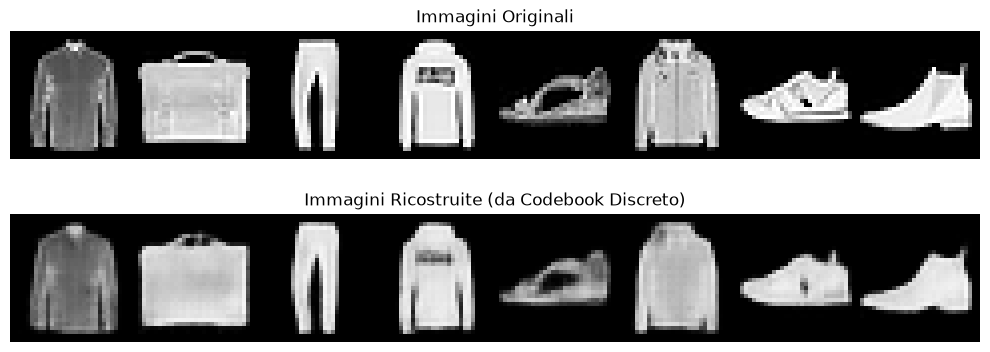

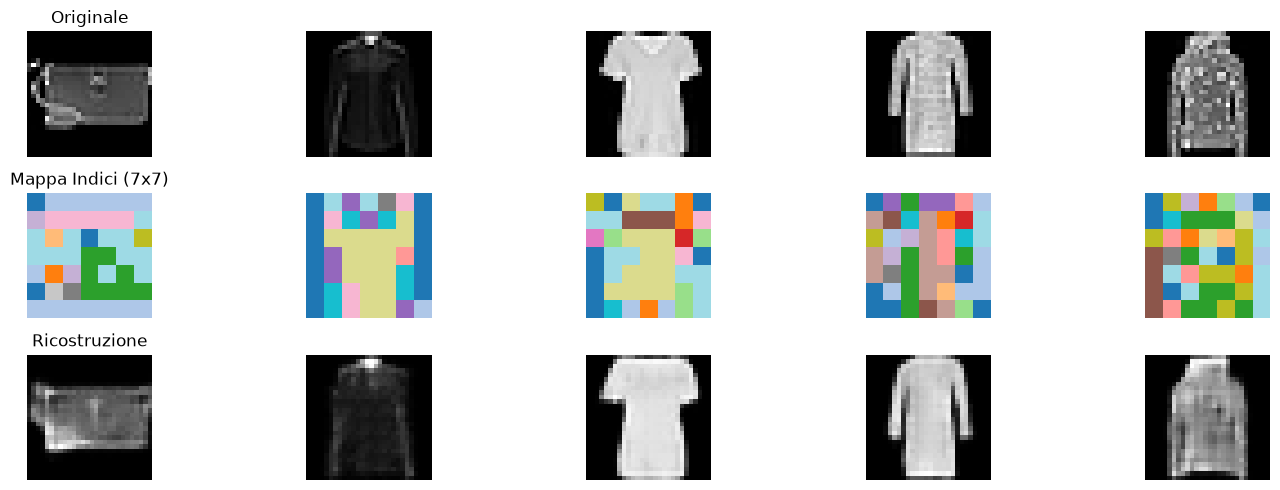

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# =============================================================================
# CONFIGURAZIONE DEI PARAMETRI E DEL DISPOSITIVO
# =============================================================================
# Impostiamo il dispositivo di calcolo: GPU se disponibile, altrimenti CPU.
device = torch.device( "cuda" if torch.cuda.is_available() else "cpu" )

# Iperparametri per il Vector Quantized Variational Autoencoder (VQ-VAE).
# num_embeddings: Dimensione del "Dizionario" (Codebook). Rappresenta quanti vettori discreti distinti
# il modello può scegliere per rappresentare l'informazione compressa.
num_embeddings = 128    

# embedding_dim: La dimensione di ciascun vettore nel codebook. Ogni "parola" del dizionario
# è un vettore di 32 numeri.
embedding_dim = 32     

# commitment_cost: Un fattore di ponderazione (beta) per la loss function.
# Serve a bilanciare quanto l'encoder deve "impegnarsi" a produrre vettori vicini a quelli del codebook.
commitment_cost = 0.25 

batch_size = 128       # Numero di immagini processate in parallelo
epochs = 10            # Numero di cicli di addestramento su tutto il dataset

# =============================================================================
# PREPARAZIONE DEI DATI (MNIST)
# =============================================================================
# Trasformazione base: converte le immagini in tensor PyTorch.
transform = transforms.Compose( [transforms.ToTensor()] )

# Caricamento del dataset MNIST. Viene scaricato automaticamente se non presente.
# Il DataLoader gestisce il caricamento in batch e il mescolamento (shuffle) dei dati.
train_loader = DataLoader(
    datasets.FashionMNIST( '.', train=True, download=True, transform=transform ),
    batch_size=batch_size,
    shuffle=True
)

# =============================================================================
# CLASSE: VECTOR QUANTIZER (IL CUORE DEL VQ-VAE)
# =============================================================================
# Questa classe gestisce la parte discreta del modello. Invece di passare vettori continui
# dall'encoder al decoder, li sostituisce con il vettore più simile presente in un "codebook" fisso.
# Riceve l'output dell'Encoder e sostituisce ogni vettore con quello più vicino
# presente nel codebook
class VectorQuantizer( nn.Module ):
    def __init__( self, num_embeddings, embedding_dim, commitment_cost ):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_embeddings = num_embeddings
        self.commitment_cost = commitment_cost
        
        # Il Codebook (o dizionario) è implementato come uno strato di Embedding.
        # Contiene 'num_embeddings' vettori, ognuno di dimensione 'embedding_dim'.
        # Questi sono i prototipi discreti che il modello imparerà ad usare.
        # non creo un dizionario statico, durante il training viene modificato
        # inizialmente i 128 vettori sono praticamente casuali
        # alla fine del training doventano rappresentazioni utili
        self.codebook = nn.Embedding( self.num_embeddings, self.embedding_dim )
        
        # Inizializzazione uniforme dei pesi del codebook per aiutare la convergenza iniziale.
        # i vettori partono molto vicini alla zero.
        self.codebook.weight.data.uniform_( -1 / num_embeddings, 1 / num_embeddings )

    def forward( self, inputs ):
        # inputs ha forma: (Batch, Canali/Dim, Altezza, Larghezza).
        # Per confrontare i vettori con il codebook, dobbiamo spostare la dimensione dei canali (Embedding Dim)
        # all'ultima posizione.
        # Trasformazione: (B, C, H, W) -> (B, H, W, C)
        inputs = inputs.permute( 0, 2, 3, 1 ).contiguous()
        
        # Appiattiamo il tensore mantenendo solo la dimensione dell'embedding all'ultima posizione.
        # Ora abbiamo una lunga lista di vettori di dimensione 'embedding_dim'.
        # Forma: (Batch * H * W, Embedding Dim)
        flat_input = inputs.view( -1, self.embedding_dim )
        
        # CALCOLO DELLE DISTANZE
        # Calcoliamo la distanza euclidea quadrata tra ogni vettore di input appiattito
        # e ogni vettore nel codebook.
        # Questo ci dice quanto ogni parte dell'immagine codificata somiglia a parole del dizionario.
        # torch.cdist calcola la distanza p-norma tra ogni coppia di vettori.
        distances = torch.cdist( flat_input, self.codebook.weight )
        
        # TROVARE L'INDICE MIGLIORE
        # Per ogni vettore di input, troviamo l'indice del vettore del codebook che ha la distanza minore.
        # Questo è il processo di discretizzazione: assegniamo ogni input al suo "centroide" più vicino.
        encoding_indices = torch.argmin( distances, dim=1 ).unsqueeze( 1 )
        
        # QUANTIZZAZIONE
        # Usiamo gli indici trovati per estrarre i vettori corrispondenti dal codebook.
        # 'quantized' contiene ora i vettori del dizionario invece dei vettori originali dell'encoder.
        # Riportiamo la forma a quella dell'input: (Batch, H, W, C)
        quantized = self.codebook( encoding_indices ).view( inputs.shape )
        
        # --- CALCOLO DELLE LOSS SPECIFICHE DEL VQ-VAE ---
        # Il VQ-VAE utilizza un approccio particolare per l'addestramento perché coinvolge 
        # componenti discrete (il codebook) e continue (encoder/decoder).
        # Dobbiamo gestire attentamente chi aggiorna chi.
        
        # 1. Codebook Loss (VQ Loss)
        # OBIETTIVO: Addestrare il Codebook.
        # Vogliamo che i vettori del codebook ('quantized') si spostino verso i vettori prodotti dall'encoder ('inputs').
        # In pratica, stiamo dicendo al dizionario: "I dati reali sono qui, spostati più vicino a loro".
        # TECNICA: Usiamo 'inputs.detach()' perché in questa fase consideriamo l'output dell'encoder come 
        # un bersaglio fisso (Ground Truth). Non vogliamo che questa loss modifichi i pesi dell'encoder, 
        # ma SOLO i pesi del codebook.
        # Gradient Flow: Codebook <--- (SI) --- Loss --- (NO/Bloccato) ---> Encoder
        vq_loss = F.mse_loss( quantized, inputs.detach() )
        
        # 2. Commitment Loss
        # OBIETTIVO: Addestrare l'Encoder a "impegnarsi" (commit).
        # Vogliamo che l'encoder produca vettori che siano già vicini ai vettori esistenti nel codebook.
        # Senza questa loss, l'encoder potrebbe produrre vettori che fluttuano selvaggiamente, rendendo 
        # il codebook instabile e la quantizzazione imprecisa (errore grande tra input e quantized).
        # TECNICA: Usiamo 'quantized.detach()' perché qui consideriamo il codebook come fisso.
        # Vogliamo spostare gli 'inputs' (e quindi aggiornare l'encoder) verso il codebook, non viceversa.
        # Gradient Flow: Codebook <--- (NO/Bloccato) --- Loss --- (SI) ---> Encoder
        commitment_loss = F.mse_loss( quantized.detach(), inputs )
        
        # La loss totale restituita da questo modulo è la somma pesata.
        # vq_loss aggiorna SOLO il codebook.
        # commitment_loss aggiorna SOLO l'encoder.
        loss = vq_loss + self.commitment_cost * commitment_loss
        
        # --- STRAIGHT-THROUGH ESTIMATOR (STE) ---
        # Questo è il passaggio cruciale per la backpropagation.
        # L'operazione di quantizzazione (argmin) non ha gradiente (gradiente zero quasi ovunque).
        # Se usassimo direttamente 'quantized', il gradiente si fermerebbe qui.
        #
        # Trucco: nel forward pass usiamo 'quantized', ma nel backward pass approssimiamo il gradiente
        # come se avessimo passato 'inputs'.
        #
        # Formula: quantized = inputs + (quantized - inputs).detach()
        #
        # Spiegazione matematica:
        # - Forward: inputs + (quantized - inputs) = quantized. (Corretto, usiamo i valori quantizzati).
        # - Backward: il termine (quantized - inputs).detach() non ha gradiente.
        #             Quindi d(quantized)/d(inputs) = d(inputs)/d(inputs) = 1.
        # Il gradiente fluisce direttamente dal decoder all'encoder copiando i gradienti da 'quantized' a 'inputs'.
        quantized = inputs + ( quantized - inputs ).detach()
        
        # Riportiamo le dimensioni all'ordine originale per i layer convoluzionali successivi (Decoder).
        # (B, H, W, C) -> (B, C, H, W)
        return quantized.permute( 0, 3, 1, 2 ).contiguous(), loss

# =============================================================================
# MODELLO COMPLETO: VQ-VAE
# =============================================================================
class VQVAE( nn.Module ):
    def __init__( self ):
        super().__init__()
        
        # ENCODER
        # Riduce l'immagine di input (28x28) in una rappresentazione latente più piccola.
        # Utilizza strati convoluzionali con stride 2 per dimezzare le dimensioni spaziali due volte.
        # Input: (Batch, 1, 28, 28) -> Output intermedio: (Batch, embedding_dim, 7, 7)
        self.encoder = nn.Sequential(
            nn.Conv2d( 1, 32, 4, stride=2, padding=1 ),  # Riduce a 14x14
            nn.ReLU(),
            nn.Conv2d( 32, 64, 4, stride=2, padding=1 ), # Riduce a 7x7
            nn.ReLU(),
            nn.Conv2d( 64, embedding_dim, 1 )           # Proietta nello spazio degli embedding (16 canali)
        )
        
        # ISTANZA DEL VECTOR QUANTIZER
        # Gestisce la discretizzazione dello spazio latente.
        self.vq = VectorQuantizer( num_embeddings, embedding_dim, commitment_cost )
        
        # DECODER
        # Ricostruisce l'immagine originale partendo dalla rappresentazione quantizzata.
        # Usa ConvTranspose2d per aumentare le dimensioni spaziali (upsampling).
        # Input: (Batch, embedding_dim, 7, 7) -> Output: (Batch, 1, 28, 28)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d( embedding_dim, 64, 4, stride=2, padding=1 ), # Aumenta a 14x14
            nn.ReLU(),
            nn.ConvTranspose2d( 64, 32, 4, stride=2, padding=1 ),            # Aumenta a 28x28
            nn.ReLU(),
            nn.Conv2d( 32, 1, 1 ),                                           # Riduce i canali a 1 (scala di grigi)
            nn.Sigmoid()                                                     # Output tra 0 e 1
        )

    def forward( self, x ):
        # 1. Encoding: otteniamo lo spazio latente continuo z_e
        z_e = self.encoder( x )
        
        # 2. Vector Quantization: otteniamo lo spazio latente discreto z_q e la loss di quantizzazione
        z_q, vq_loss = self.vq( z_e )
        
        # 3. Decoding: ricostruiamo l'immagine partendo dai vettori discreti
        x_recon = self.decoder( z_q )
        
        return x_recon, vq_loss

# =============================================================================
# CICLO DI ADDESTRAMENTO
# =============================================================================
# Istanziamo il modello e lo spostiamo sul device (GPU/CPU)
model = VQVAE().to( device )

# Ottimizzatore Adam per aggiornare i pesi di Encoder, Decoder e Codebook
optimizer = optim.Adam( model.parameters(), lr=1e-3 )

print( "Inizio addestramento VQ-VAE..." )

for epoch in range( epochs ):
    model.train() # Imposta il modello in modalità training
    total_loss = 0
    
    for data, _ in train_loader:
        # Spostiamo i dati sul device corretto
        data = data.to( device )
        
        # Azzeriamo i gradienti accumulati nel passo precedente
        optimizer.zero_grad()
        
        # Forward pass: otteniamo la ricostruzione e la loss del quantizzatore
        recon, vq_loss = model( data )
        
        # Calcoliamo la Reconstruction Loss (errore di ricostruzione)
        # Misura quanto l'immagine ricostruita è simile all'originale
        recon_loss = F.mse_loss( recon, data )
        
        # La Loss totale è la somma dell'errore di ricostruzione e dell'errore di quantizzazione
        loss = recon_loss + vq_loss
        
        # Backward pass: calcolo dei gradienti
        loss.backward()
        
        # Aggiornamento dei pesi
        optimizer.step()
        
        total_loss += loss.item()
        
    # Stampa della loss media per l'epoca corrente
    print( f"Epoca {epoch+1}/{epochs}, Loss Media: {total_loss / len(train_loader):.4f}" )

# =============================================================================
# VISUALIZZAZIONE DEI RISULTATI
# =============================================================================
model.eval() # Imposta il modello in modalità valutazione (disabilita dropout, batchnorm training, ecc.)
with torch.no_grad():
    # Prendiamo un batch di dati di test
    data, _ = next( iter( train_loader ) )
    data = data.to( device )
    
    # Passiamo i dati nel modello per ottenere le ricostruzioni
    recon, _ = model( data )
    
    # Visualizziamo Originale vs Ricostruito
    fig, ax = plt.subplots( 2, 1, figsize=(10, 4) )
    
    # Immagini originali
    ax[0].imshow( utils.make_grid( data[:8] ).permute( 1, 2, 0 ).cpu() )
    ax[0].set_title( "Immagini Originali" )
    ax[0].axis( "off" )
    
    # Immagini ricostruite dal codebook discreto
    ax[1].imshow( utils.make_grid( recon[:8] ).permute( 1, 2, 0 ).cpu() )
    ax[1].set_title( "Immagini Ricostruite (da Codebook Discreto)" )
    ax[1].axis( "off" )
    
    plt.tight_layout()
    plt.show()

# =============================================================================
# VISUALIZZAZIONE DEL CODEBOOK (GLI "ATOMI" APPRESI)
# =============================================================================


def visualize_index_map(model, loader):
    model.eval()
    with torch.no_grad():
        # Prendiamo un batch di immagini reali
        images, _ = next(iter(loader))
        images = images.to(device)
        
        # Passiamo dall'encoder
        z_e = model.encoder(images)
        
        # Calcoliamo le distanze dal codebook per trovare gli indici
        # (Riprendiamo la logica interna del VectorQuantizer)
        z_e_flattened = z_e.permute(0, 2, 3, 1).contiguous().view(-1, embedding_dim)
        distances = torch.cdist(z_e_flattened, model.vq.codebook.weight)
        indices = torch.argmin(distances, dim=1).view(images.shape[0], 7, 7)
        
        # Visualizzazione
        num_examples = 5
        plt.figure(figsize=(15, 5))
        for i in range(num_examples):
            # Immagine Originale
            plt.subplot(3, num_examples, i + 1)
            plt.imshow(images[i].cpu().squeeze(), cmap='gray')
            plt.axis('off')
            if i == 0: plt.title("Originale")

            # Mappa degli Indici (Colorata)
            # Ogni quadratino colorato corrisponde a un "atomo" del codebook
            plt.subplot(3, num_examples, i + num_examples + 1)
            plt.imshow(indices[i].cpu().numpy(), cmap='tab20') 
            plt.axis('off')
            if i == 0: plt.title("Mappa Indici (7x7)")

            # Ricostruzione Finale
            plt.subplot(3, num_examples, i + 2*num_examples + 1)
            recon, _ = model(images[i].unsqueeze(0))
            plt.imshow(recon.cpu().squeeze(), cmap='gray')
            plt.axis('off')
            if i == 0: plt.title("Ricostruzione")
            
        plt.tight_layout()
        plt.show()

# Eseguiamo la nuova visualizzazione
visualize_index_map(model, train_loader)